In [51]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings 
warnings.filterwarnings('ignore')
# Show all columns without truncation
pd.set_option("display.max_columns", None)

# Set the seaborn theme to darkgrid
sns.set_theme(style='darkgrid')

In [52]:
df = pd.read_csv('D:\Customer-Churn-Analytics\Data\Featured_superstore.csv')
df.head(5)


,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,postal_code,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,cost,profit_margin,shipping_days,order_year,order_month,order_quarter,order_days
0,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,220.0464,16.00,3,2016,11,4,8
1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,512.3580,30.00,3,2016,11,4,8
2,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,7.7486,47.00,4,2016,6,2,12
3,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,1340.6085,-40.00,7,2015,10,4,11
4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,19.8516,11.25,7,2015,10,4,11


In [53]:
df[['sales', 'quantity', 'discount', 'profit', 'cost',
       'profit_margin', 'shipping_days']].describe().round(2)

,sales,quantity,discount,profit,cost,profit_margin,shipping_days
count,9994.00,9994.00,9994.00,9994.00,9994.00,9994.00,9994.00
mean,229.86,3.79,0.16,28.66,201.20,12.03,3.96
std,623.25,2.23,0.21,234.26,550.84,46.68,1.75
min,0.44,1.00,0.00,-6599.98,0.55,-275.00,0.00
25%,17.28,2.00,0.00,1.73,12.69,7.50,3.00
50%,54.49,3.00,0.20,8.67,41.66,27.00,4.00
75%,209.94,5.00,0.20,29.36,182.23,36.25,5.00
max,22638.48,14.00,0.80,8399.98,24449.56,50.00,7.00


---
# 1- Univariate Analysis
---

### profit Distribution and Outlier Detection

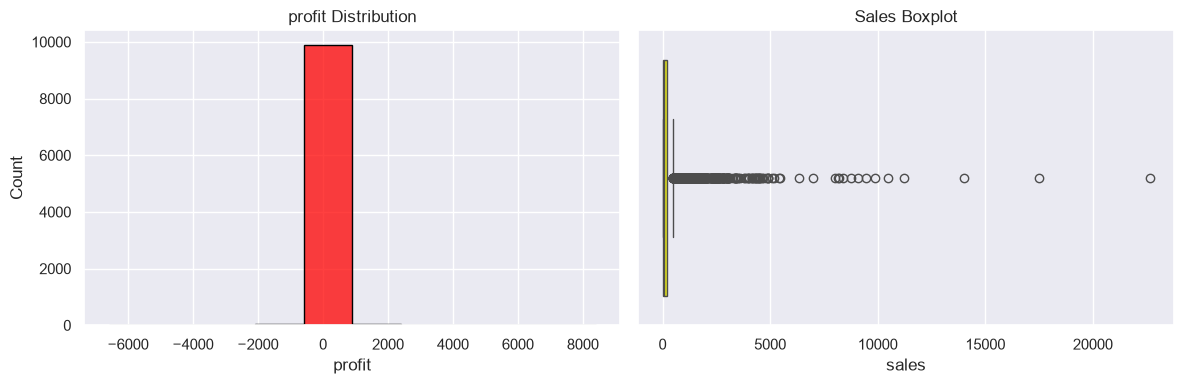

In [114]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

# First plot
sns.histplot(df['profit'], bins= 10, ax=axes[0], color='red', edgecolor='black')
axes[0].set_title("profit Distribution")

# Second plot
sns.boxplot(x=df['sales'], ax=axes[1], color='yellow')
axes[1].set_title("Sales Boxplot")

plt.tight_layout()
plt.show()

### Observations 
* found data is extreme right skewed
* mostly sales amount occur between 100$ - 2500$  
* the highest sales amount is 22638.48$ where the lowest is 17.2$
* observed sales prone to outliers
----

### Quantity Distribution 

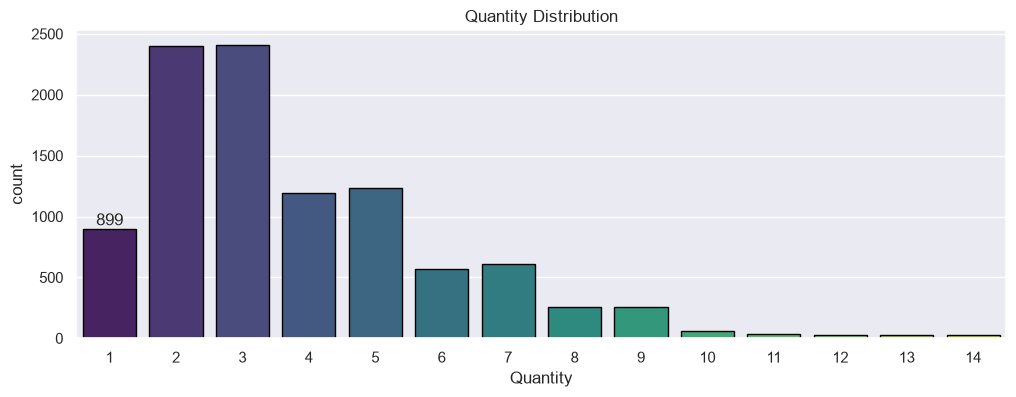

In [119]:
plt.figure(figsize=(12,4))

# creating countplot
ax = sns.countplot(x= df['quantity'], edgecolor='black', color='lightblue', palette='viridis')

# adding titles
plt.title('Quantity Distribution')
plt.xlabel('Quantity')

# Add values on top of each bar
ax.bar_label(ax.containers[0], padding=0)
plt.show()

### Observations
* customers are tend to orders mostly in **quantities of 2-3 items** per transaction
* The most frequent order size is 3 units, The least frequent order size is 14 units
* The quantity distribution is **strongly right-skewed**
* On average, typical customer purchases cluster tightly around 2–3 products per order.
----

### Discount Distribution

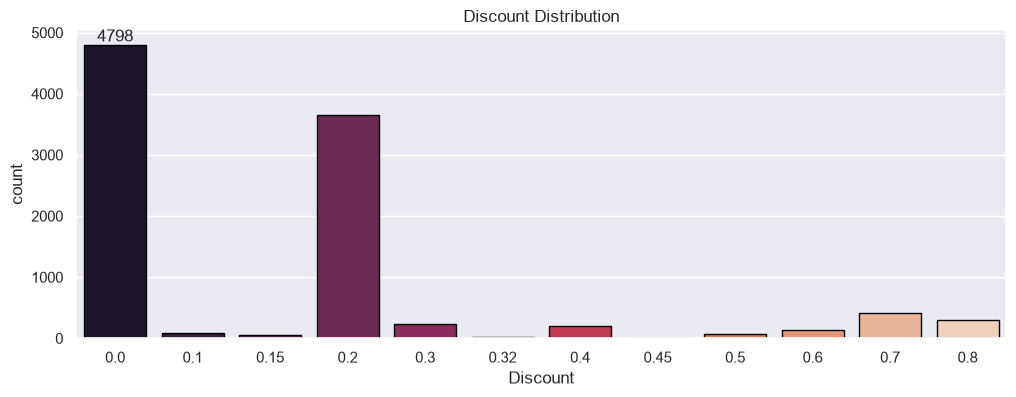

In [120]:

plt.figure(figsize=(12,4))

# Set the seaborn theme to darkgrid
sns.set_theme(style='darkgrid') 

# creating countplot
ax = sns.countplot(x= df['discount'], edgecolor='black', color='r', palette='rocket')

# adding titles
plt.title('Discount Distribution')
plt.xlabel('Discount')

# Add values on top of each bar
ax.bar_label(ax.containers[0], padding=0)
plt.show()

### Observations
* The majority of orders (4,798 transactions) receive no discount (0.0).
* Among discounted orders, a **20% discount (0.2)** is by far the most popular promotion offered, appearing in 3,657 orders.
* The discount data is **right-skewed**
---

### Profit Disctribution and Outliers Detection`

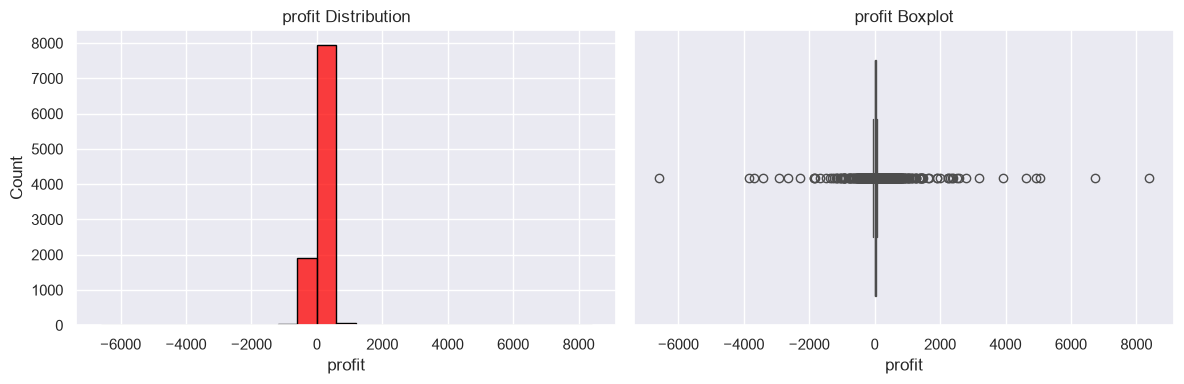

In [121]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

# Set the seaborn theme to darkgrid
sns.set_theme(style='darkgrid')

# First plot
sns.histplot(df['profit'], bins= 25, ax=axes[0], color='red', edgecolor='black')
axes[0].set_title("profit Distribution")

# Second plot
sns.boxplot(x=df['profit'], ax=axes[1], color='yellow')
axes[1].set_title("profit Boxplot")

plt.tight_layout()
plt.show()

### Observations
* Profit values range from big losses ($6,500$) to high profits ($8,500$).
* Most transactions make small profit between 0$ to 100$
* Extreme profit and loss values are in the dataset so has higher outlier count
---

### Cost Distribution

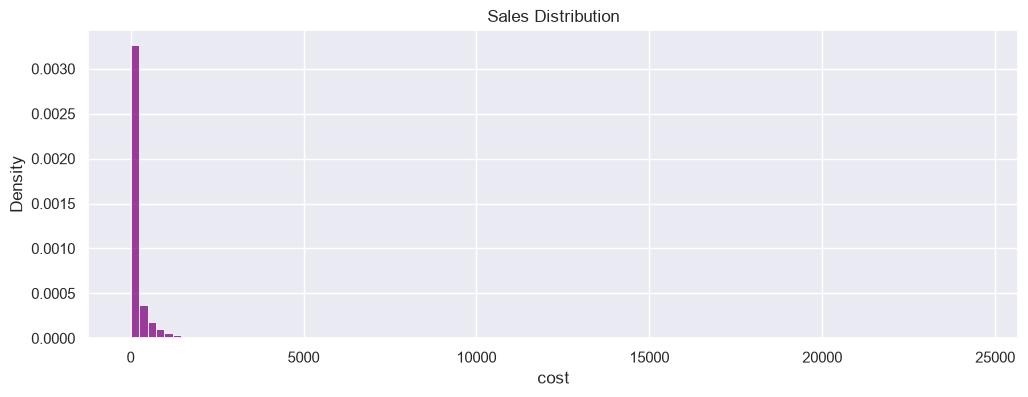

In [58]:
plt.figure(figsize=(12,4))

# Set the seaborn theme to darkgrid
sns.set_theme(style='darkgrid')

# First plot
sns.histplot(df['cost'], bins=100 , color='purple', stat='density')
plt.title("Sales Distribution")

plt.show()

### Observations
* The average cost per order is around $201 (mean), but most orders are much cheaper (under $500).
* Cost ranges from $0 up to nearly $25,000 for rare large orders.
* The cost distribution is strongly right-skewed, as almost all transactions have low product costs
---

### Shipping Distribution

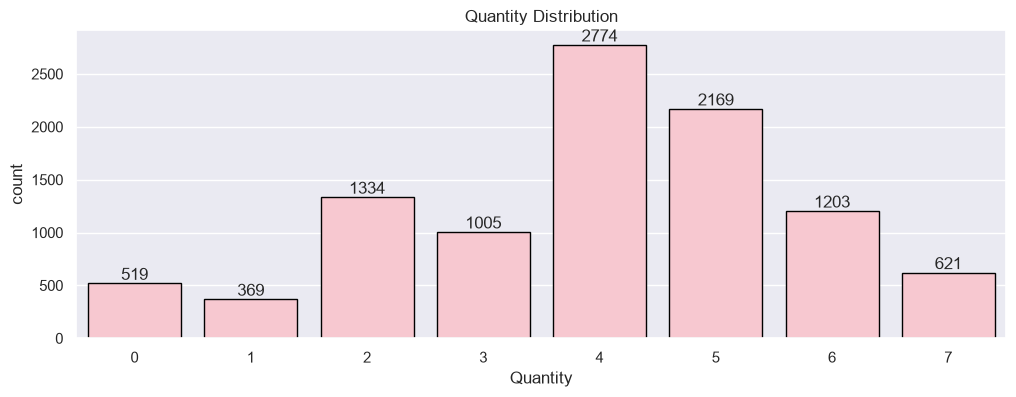

In [59]:
plt.figure(figsize=(12,4))

# Set the seaborn theme to darkgrid
sns.set_theme(style='darkgrid')

# creating countplot
ax = sns.countplot(x= df['shipping_days'], edgecolor='black', color='pink')

# adding titles
plt.title('Quantity Distribution')
plt.xlabel('Quantity')

# Add values on top of each bar
ax.bar_label(ax.containers[0], padding=0)
plt.show()

### Observations
* Most orders take **4 to 5 days** to ship (4 days is the highest at 2,774 orders, followed by 5 days at 2,169 orders).
* Only **519 orders** were shipped on the same day (0 days).
* A small number of orders (**621 orders**) took the maximum time of **7 days** to ship.
---

### Region wise Orders

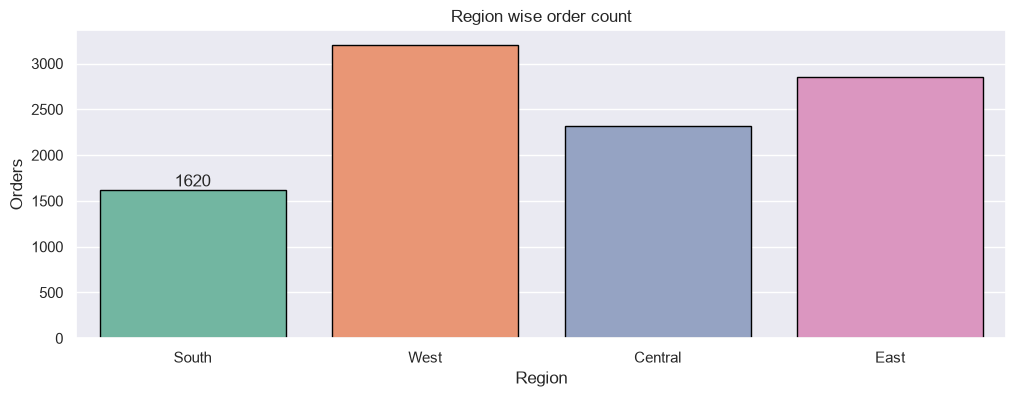

In [123]:
plt.figure(figsize=(12,4))

# Set the seaborn theme to darkgrid
sns.set_theme(style='darkgrid')

# creating countplot
ax = sns.countplot(x= df['region'], edgecolor='black', color='lightgreen', palette='Set2')

# adding titles
plt.title('Region wise order count')
plt.xlabel('Region')
plt.ylabel('Orders')

# Add values on top of each bar
ax.bar_label(ax.containers[0], padding=0)
plt.show()

### Observations
The West region has the largest number of orders,
indicating it is the company's strongest market. 
The South region has the fewest orders, suggesting an opportunity for targeted marketing campaigns or expansion strategies.

---

### Category wise Orders


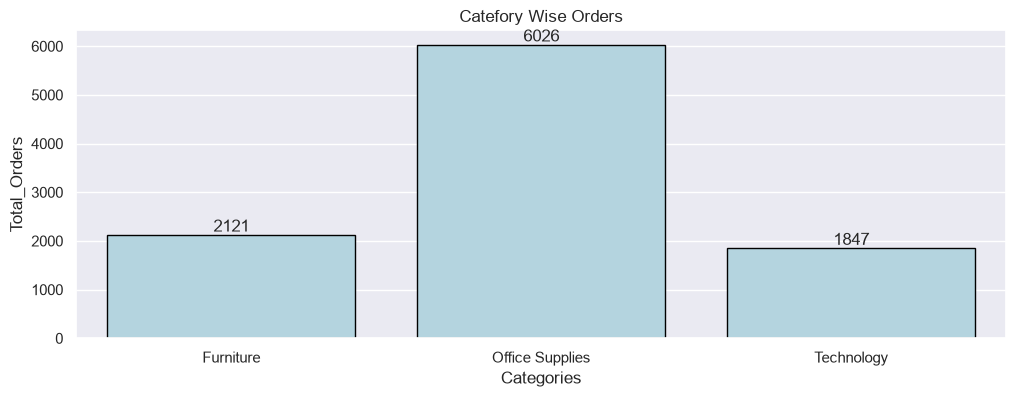

In [61]:
plt.figure(figsize=(12,4))

# Set the seaborn theme to darkgrid
sns.set_theme(style='darkgrid')

# creating countplot
ax = sns.countplot(x= df['category'], edgecolor='black', color='lightblue')

# adding titles
plt.title('Catefory Wise Orders')
plt.xlabel('Categories')
plt.ylabel('Total_Orders')

# Add values on top of each bar
ax.bar_label(ax.containers[0], padding=0)
plt.show()

### Observations
customers are more tend to buy Office Supplies than Furniture and Technology, The Technology has the lowest Order count with 1847 orders only, whereas Furniture performed better with 2121 orders. 

---

## Sub_category Wise Orders

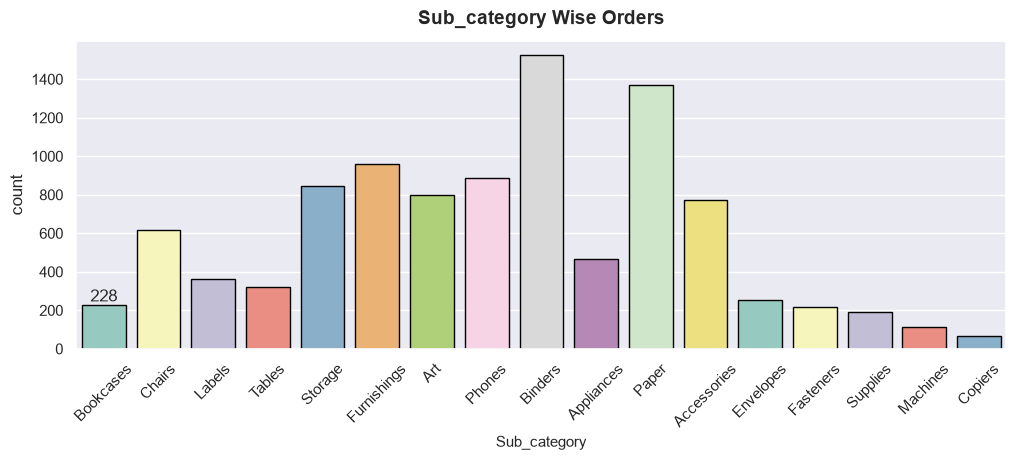

In [124]:
plt.figure(figsize=(12,4))

# Set the seaborn theme to darkgrid
sns.set_theme(style='darkgrid')

# creating countplot
ax = sns.countplot(x= df['sub_category'], edgecolor='black', color='purple', palette='Set3')

# adding titles
plt.title('Sub_category Wise Orders',fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Sub_category', fontsize=11)

# Add values on top of each bar
ax.bar_label(ax.containers[0], padding=0)
plt.xticks(rotation=45)
plt.show()

### Observation
Binders are our most selling sub category with 1523 of total orders, when other sub categories are performing well too mostly between 800 - 1500,
Copiers is the least selling sub category with 68 orders only.

---

## Ship mode Wise Orders

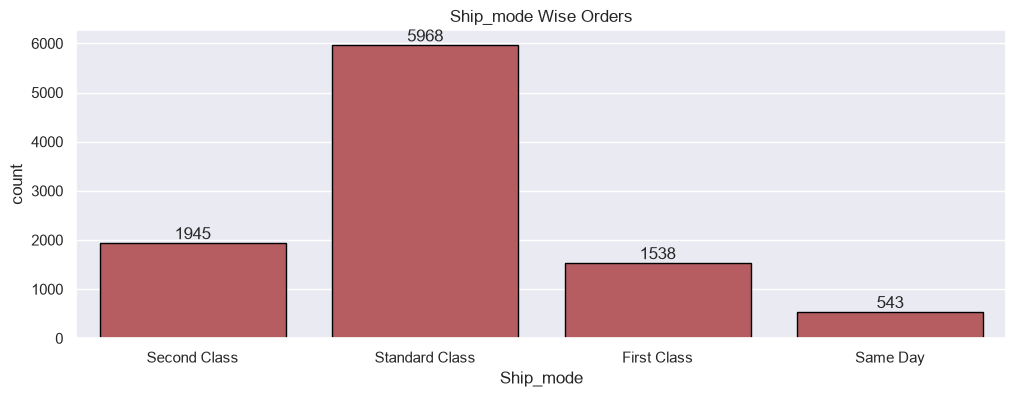

In [63]:
plt.figure(figsize=(12,4))

# creating countplot
ax = sns.countplot(x= df['ship_mode'], edgecolor='black', color='r')

# adding titles
plt.title('Ship_mode Wise Orders')
plt.xlabel('Ship_mode')

# Add values on top of each bar
ax.bar_label(ax.containers[0], padding=0)
plt.show()

### Observation
Most customers prefer Standard Class shipping, indicating cost is likely more important than delivery speed. Faster shipping services appear to be used less frequently and may appeal only to specific customer groups.

----

---
# 2- Bivariate Analysis
---

### Region Wise Sales

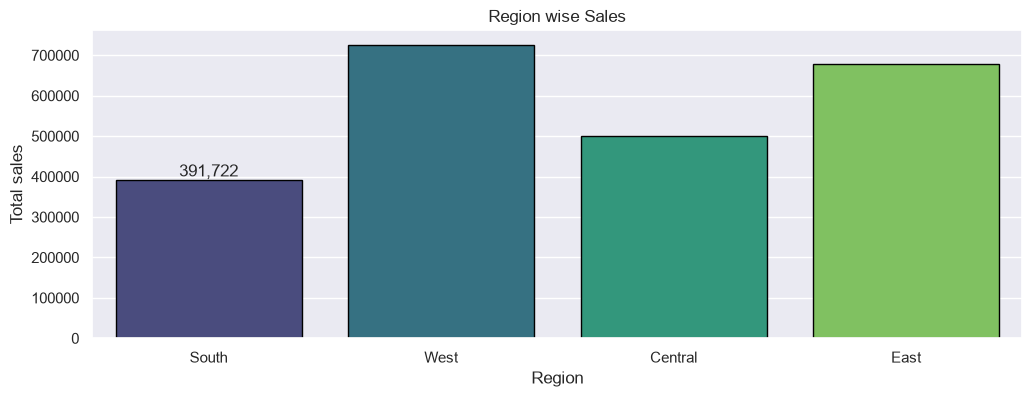

In [126]:
plt.figure(figsize=(12,4))

# creating Barplot 
ax = sns.barplot(data=df, x='region', y='sales', estimator='sum', errorbar=None, edgecolor='black', color='yellow', palette='viridis')

# adding titles
plt.title('Region wise Sales')
plt.xlabel('Region')
plt.ylabel('Total sales')

# Add values on top of each bar
ax.bar_label(ax.containers[0], fmt='{:,.0f}')
plt.show()

### Observation
The highest sales region is **West** with a total of $725,458, which means our customers are mostly from west region, **East** also contributed well by giving $678,781 of total sales whereas the lowest sales observed in **South** with only $391,722 of total sales 

---

### Region Wise Profit

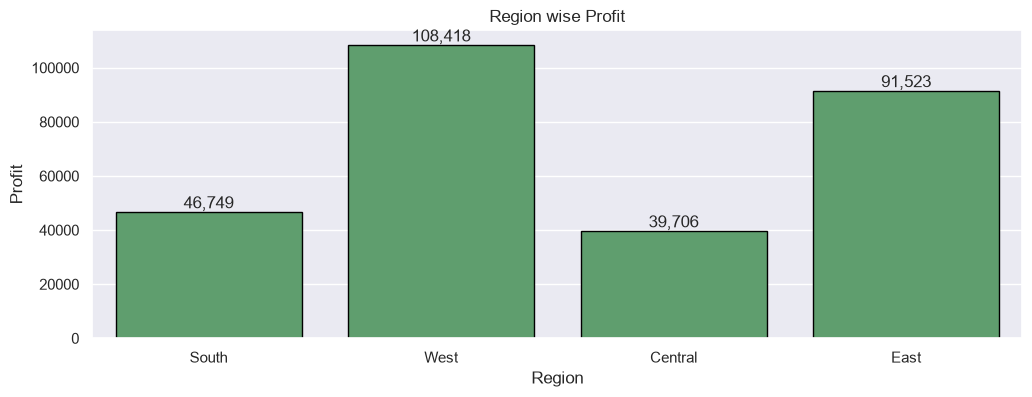

In [65]:
plt.figure(figsize=(12,4))

# creating Barplot 
ax = sns.barplot(data=df, x='region', y='profit', estimator='sum', errorbar=None, edgecolor='black', color='g')

# adding titles
plt.title('Region wise Profit')
plt.xlabel('Region')
plt.ylabel('Profit')

# Add values on top of each bar
ax.bar_label(ax.containers[0], fmt='{:,.0f}')
plt.show()

### Observation
West generated the highest profit ($108,418), followed by East ($91,523), The South and Central regions contributed significantly lower profits.

---

### Category Wise Sales

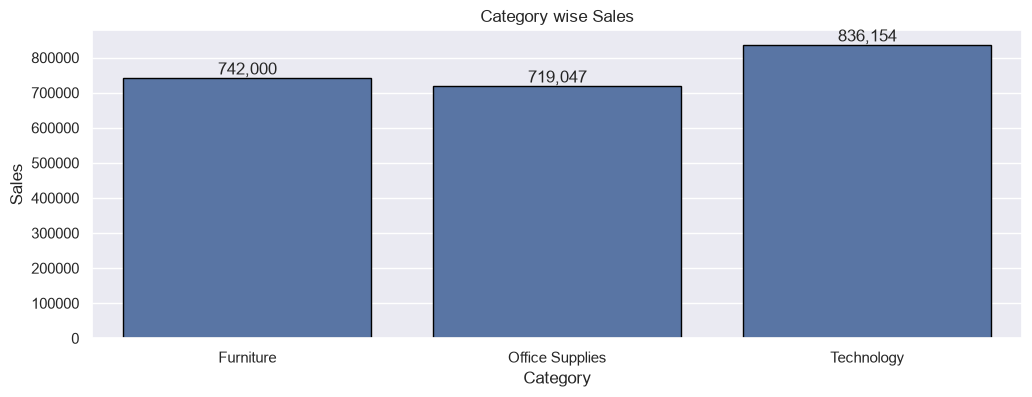

In [66]:
plt.figure(figsize=(12,4))

# creating Barplot 
ax = sns.barplot(data=df, x='category', y='sales', estimator='sum', errorbar=None, edgecolor='black', color='b')

# adding titles
plt.title('Category wise Sales')
plt.xlabel('Category')
plt.ylabel('Sales')

# Add values on top of each bar
ax.bar_label(ax.containers[0], fmt='{:,.0f}')
plt.show()

### Observation
Technology recorded the highest sales (836,154), followed by Furniture (742,000). Office Supplies generated the lowest sales (719,047), indicating that Technology was the best-performing category in terms of sales.

---

### Category Wise Profit

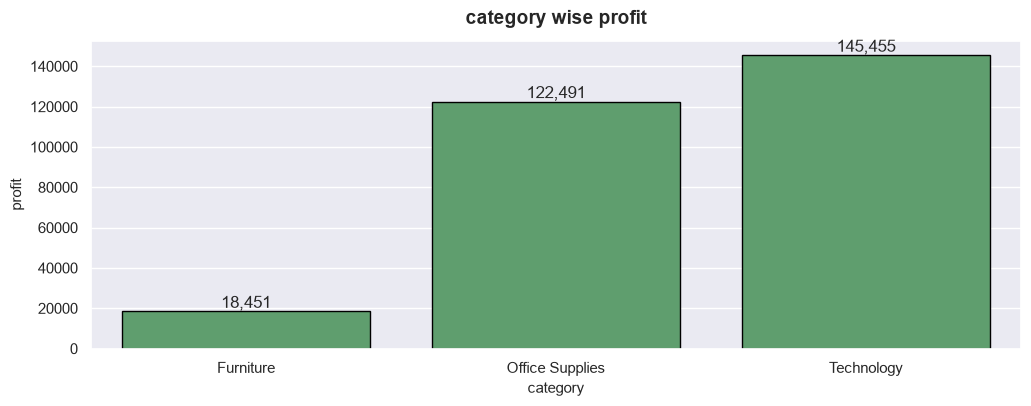

In [67]:
plt.figure(figsize=(12,4))

# creating Barplot 
ax = sns.barplot(data=df, x='category', y='profit', estimator='sum', errorbar=None, edgecolor='black', color='g')

# adding titles
plt.title('category wise profit', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('category', fontsize=11)
plt.ylabel('profit', fontsize=11)

# Add values on top of each bar
ax.bar_label(ax.containers[0], fmt='{:,.0f}')
plt.show()

### Observation
Technology Category performed significantly better than the remaining categories gave ($145,455) profit, followd by Office Supplies Category ($122,491), whereas Furniture Category showed comparatively weaker performance with only ($18,451) of profit, This signifies most sales and profit occurs because of Technology Category

---

### Sales by Sub-Category

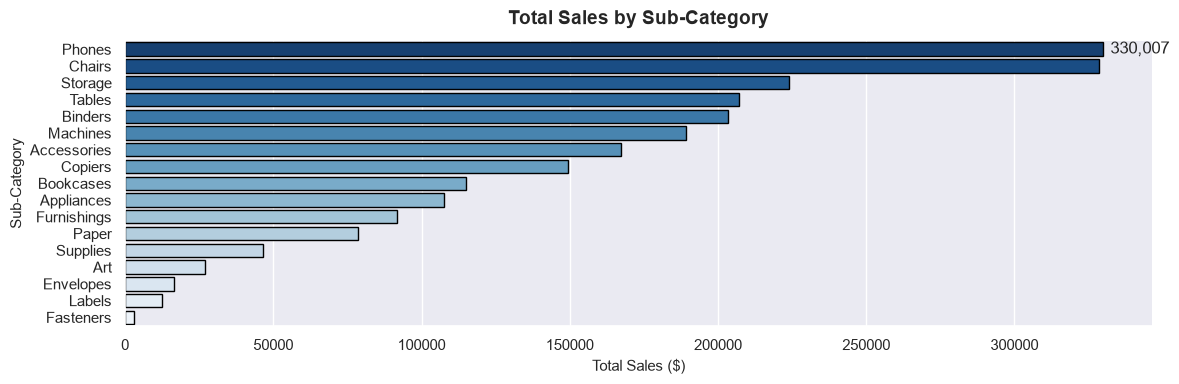

In [76]:
# Group subcategory by sales 
subcat_sales = df.groupby('sub_category')['sales'].sum().reset_index()
# Sort sub-categories by total sales descending
subcat_sales = subcat_sales.sort_values(by='sales', ascending=False)

plt.figure(figsize=(12,4))

# Create Horizontal Barplot 
ax = sns.barplot(data=subcat_sales, x='sales', y='sub_category', edgecolor='black', color='m', palette='Blues_r')

# Title and labels
plt.title('Total Sales by Sub-Category', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Total Sales ($)', fontsize=11)
plt.ylabel('Sub-Category', fontsize=11)

# Add values on top of each bar
ax.bar_label(ax.containers[0], fmt='{:,.0f}', padding=5)

plt.tight_layout()
sns.despine(top=True, right=True)
plt.show()

### Observation
Phones generated the highest total sales ($330,007), closely followed by Chairs ($328,449). Storage, Tables, and Binders also contributed significantly to total sales. On the other hand, Fasteners ($3,024), Labels ($12,486), and Envelopes ($16,476) recorded the lowest sales.

---

### Profit By Sub Category

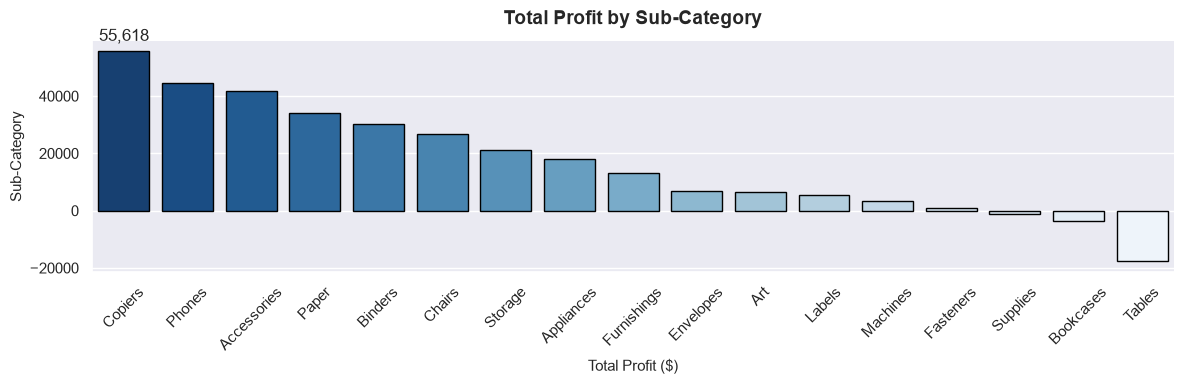

In [75]:
# Group subcategory by profit 
subcat_profit = df.groupby('sub_category')['profit'].sum().reset_index()
# Sort sub-categories by total sales descending
subcat_profit = subcat_profit.sort_values(by='profit', ascending=False)

plt.figure(figsize=(12,4))

# Create Horizontal Barplot 
ax = sns.barplot(data=subcat_profit, x='sub_category', y='profit', edgecolor='black', color='g', palette='Blues_r')

# Title and labels
plt.title('Total Profit by Sub-Category', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Total Profit ($)', fontsize=11)
plt.ylabel('Sub-Category', fontsize=11)
plt.xticks(rotation=45)

# Add values on top of each bar
ax.bar_label(ax.containers[0], fmt='{:,.0f}', padding=5)

plt.tight_layout()
sns.despine(top=True, right=True)
plt.show()

### Observation
Copiers generated the highest total profit ($55,618), followed by Phones ($44,516), Accessories ($41,937), and Paper ($34,054). Most sub-categories were profitable, while Tables (-$17,725), Bookcases (-$3,473), and Supplies (-$1,189) recorded losses. These losses may be associated with higher discounts or lower profit margins.

---

### Year Wise Sales

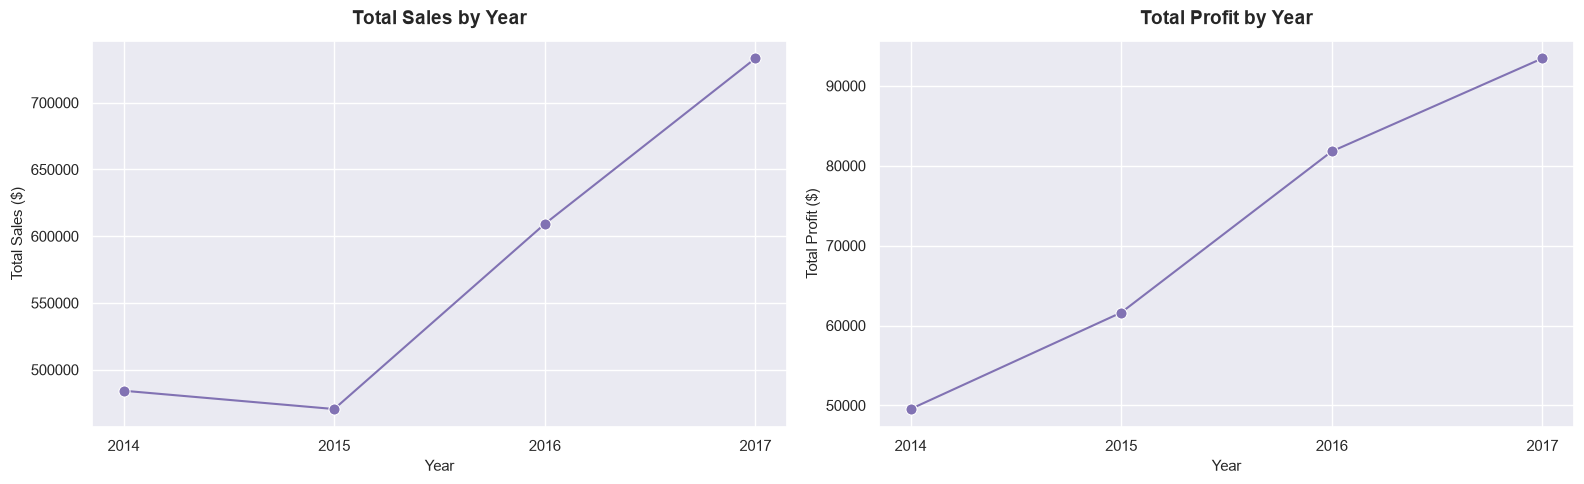

In [73]:
# Aggregate Sales and Profit by Year
yearly_sales = df.groupby('order_year')['sales'].sum().reset_index()
yearly_profit = df.groupby('order_year')['profit'].sum().reset_index()

# Create Subplot Figure (1 Row, 2 Columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# --- Left Plot: Total Sales by Year ---
sns.lineplot(data=yearly_sales, x='order_year', y='sales', color='m', marker='o', ms=8, ax=ax1)

ax1.set_title('Total Sales by Year', fontsize=14, fontweight='bold', pad=12)
ax1.set_ylabel('Total Sales ($)', fontsize=11)
ax1.set_xlabel('Year', fontsize=11)
ax1.set_xticks([2014, 2015, 2016, 2017])

# --- Right Plot: Total Profit by Year ---
sns.lineplot(data=yearly_profit, x='order_year', y='profit', color='m', marker='o', ms=8, ax=ax2)

ax2.set_title('Total Profit by Year', fontsize=14, fontweight='bold', pad=12)
ax2.set_ylabel('Total Profit ($)', fontsize=11)
ax2.set_xlabel('Year', fontsize=11)
ax2.set_xticks([2014, 2015, 2016, 2017])

# Adjust spacing between plots
plt.tight_layout()
plt.show()

### Observation
Sales showed an overall upward trend after 2015 and is significantly increasing whereas As sales increased after 2015, profit also increased along with it. we can in the above charts both total sales and total profit reached their highest levels in 2017.

---

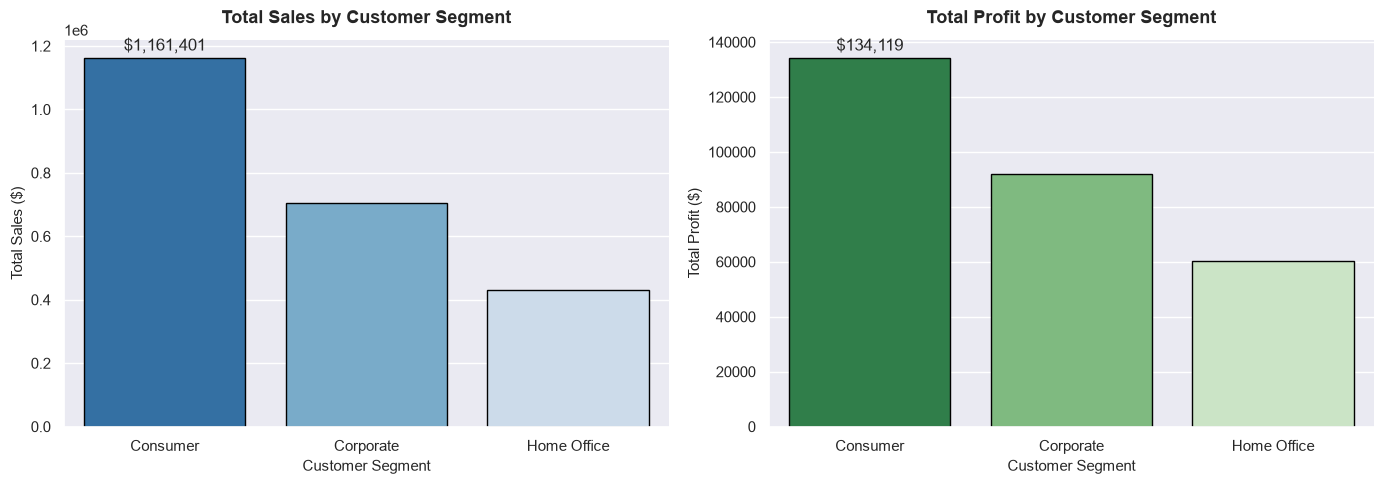

In [ ]:
# Group data by Segment
segment_sales = df.groupby('segment')['sales'].sum().reset_index().sort_values(by='sales', ascending=False)
segment_profit = df.groupby('segment')['profit'].sum().reset_index().sort_values(by='profit', ascending=False)

# Create Subplot Figure (1 Row, 2 Columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Left Plot: Total Sales ---
sns.barplot(data=segment_sales, x='segment', y='sales', palette='Blues_r', edgecolor='black', ax=ax1)

ax1.set_title('Total Sales by Customer Segment', fontsize=13, fontweight='bold', pad=12)
ax1.set_xlabel('Customer Segment', fontsize=11)
ax1.set_ylabel('Total Sales ($)', fontsize=11)
ax1.bar_label(ax1.containers[0], fmt='${:,.0f}', padding=3)

# --- Right Plot: Total Profit ---
sns.barplot(data=segment_profit, x='segment', y='profit', palette='Greens_r', edgecolor='black', ax=ax2)

ax2.set_title('Total Profit by Customer Segment', fontsize=13, fontweight='bold', pad=12)
ax2.set_xlabel('Customer Segment', fontsize=11)
ax2.set_ylabel('Total Profit ($)', fontsize=11) 
ax2.bar_label(ax2.containers[0], fmt='${:,.0f}', padding=3)

# Clean borders and layout
sns.despine()
plt.tight_layout()
plt.show()


### Observations
The **Consumer** segment spends the most and generates the highest total profit for the company, The **Corporate** segment comes second in both total sales and total profit, **Lowest Segment:** The **Home Office** segment brings in the lowest sales and profit compared to the other two segments.

## 3- Multi-Variate Analysis


### Discount vs Profit by Category

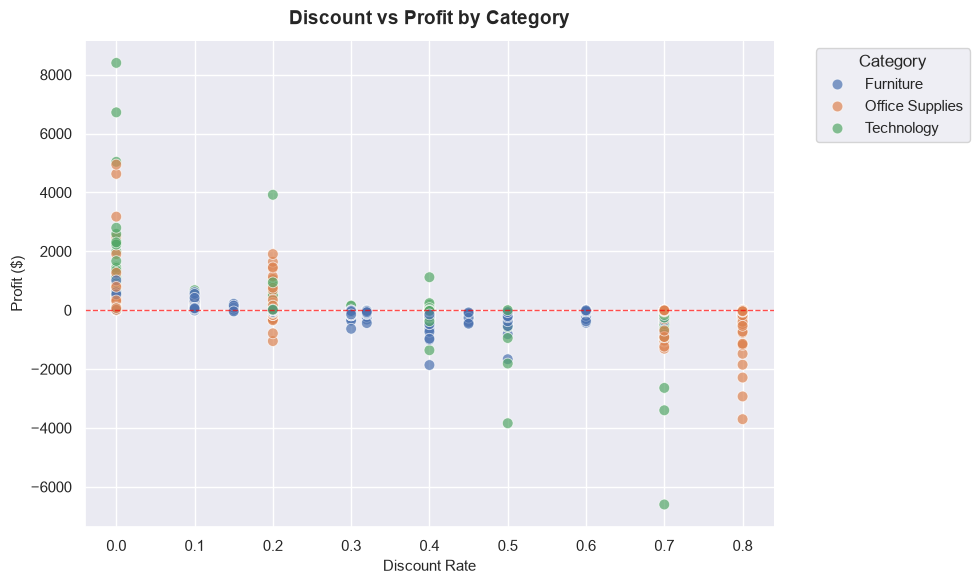

In [92]:
plt.figure(figsize=(10, 6))

# Scatter plot
sns.scatterplot(data=df, x='discount', y='profit', hue='category', alpha=0.7, s=60)

# Title and labels
plt.title('Discount vs Profit by Category', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Discount Rate', fontsize=11)
plt.ylabel('Profit ($)', fontsize=11)

# Add a horizontal line at 0 profit to highlight losses
plt.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.7)

# Move legend outside so it doesn't block data points
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')

sns.despine()
plt.tight_layout()
plt.show()

### Observations
As discounts increase (especially above 0.2 / 20%), profits drop drastically into negative numbers, Most high-profit orders occur when no discount (0.0) is given, Heavy discounts on Technology items result in the largest financial losses. Even after giving highers discounts in Office Suppliers still got Negative numbers in profit

---

### Sales Vs Profit By Segment

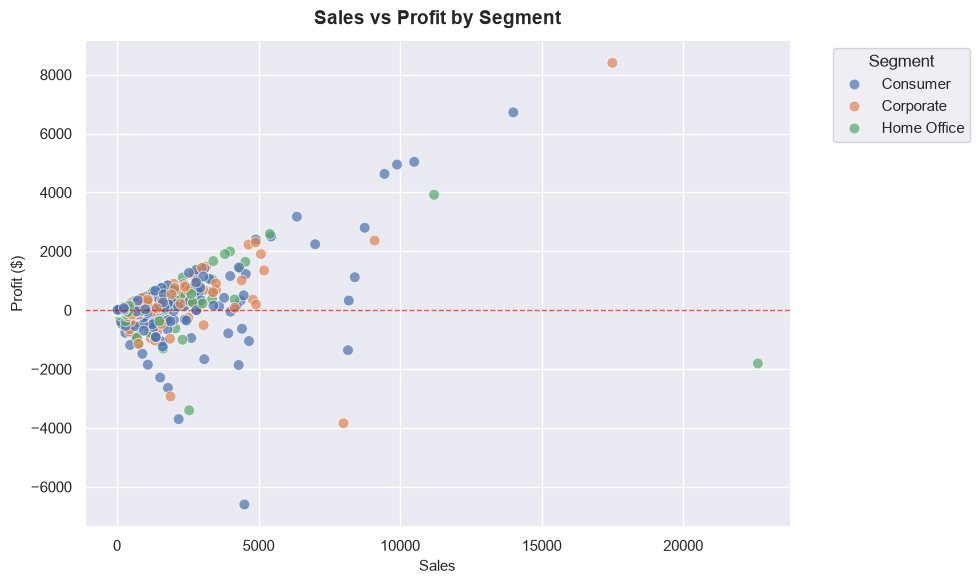

In [103]:
plt.figure(figsize=(10, 6))

# Scatter plot
sns.scatterplot(data=df, x='sales', y='profit', hue='segment', alpha=0.7, s=60)

# Title and labels
plt.title('Sales vs Profit by Segment', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Sales', fontsize=11)
plt.ylabel('Profit ($)', fontsize=11)

# Add a horizontal line at 0 profit to highlight losses
plt.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.7)

# Move legend outside so it doesn't block data points
plt.legend(title='Segment', bbox_to_anchor=(1.05, 1), loc='upper left')

sns.despine()
plt.tight_layout()
plt.show()


### Observations
As sales increase, profit also increases across all segments, High sales do not always mean high profit. Some large orders (over $4,000 in sales) resulted in massive losses of -$2,000 to -$6,000 due to heavy discounting

---

### Sales by Ship Mode and Region

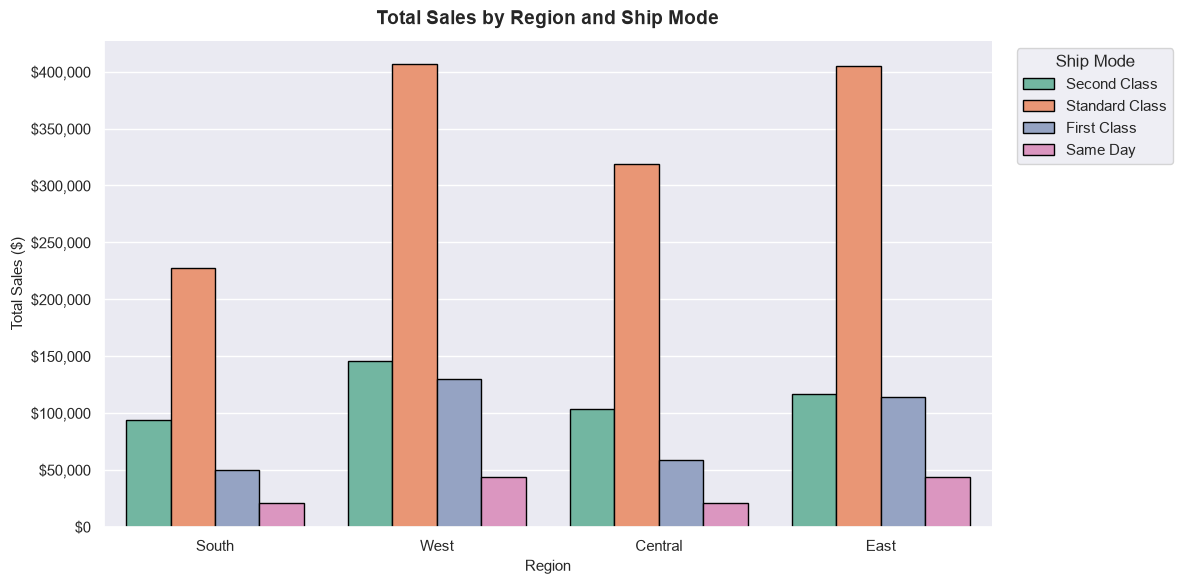

In [113]:

plt.figure(figsize=(12, 6))

# Clustered Bar Plot
ax = sns.barplot(
    data=df, 
    x='region', 
    y='sales', 
    hue='ship_mode', 
    estimator=sum,      # Shows Total Sales
    ci=None,            # Removes error bars
    palette='Set2', 
    edgecolor='black'
)

# Titles and Labels
plt.title('Total Sales by Region and Ship Mode', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Region', fontsize=11)
plt.ylabel('Total Sales ($)', fontsize=11)

# Format y-axis values cleanly
ax.yaxis.set_major_formatter('${x:,.0f}')

# Move legend outside the plot
plt.legend(title='Ship Mode', bbox_to_anchor=(1.02, 1), loc='upper left')

# Remove top and right borders
sns.despine()

plt.tight_layout()
plt.show()

### Observations
**Standard Class** generates the highest total sales across every region, The **West** region brings in the overall highest sales for most shipping methods.
**Same Day** shipping accounts for the lowest total sales across all regions.

### Correlation between Sales, Profit, Discount and Quantity

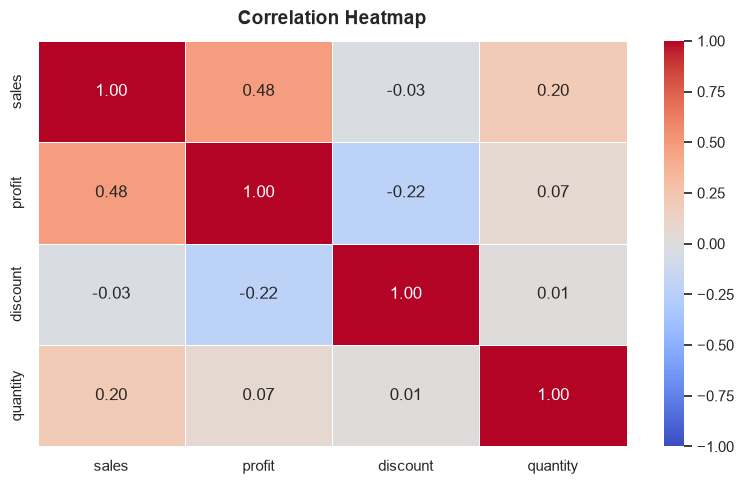

In [110]:
plt.figure(figsize=(8, 5))

# Calculate correlation matrix
corr_num = df[['sales', 'profit', 'discount', 'quantity']].corr()

# Plot Heatmap with formatting
sns.heatmap(corr_num, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5,vmin=-1, vmax=1)

# Title
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold', pad=12)

plt.tight_layout()
plt.show()

### Observations
* Sales and Profit are partilly correlated (0.48) to each other meaning if sales incresess profit will also increase
* Profit and Discount are negatively correlated (-0.22) means as discounts increase, profit tends to decrease
